In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

df = pd.read_csv('../dataset/final_dataset.csv')
df.columns = df.columns.astype(str).str.strip().str.replace(' ', '_')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.sort_values('date')
df.head(10)

,date,inflation,rice_price,chili_price,meat_price,egg_price,restaurant_inflation,rainfall,lag_inflation,lag_1,lag_2,rolling_3,inflation_momentum,rice_price_pct_change,chili_price_pct_change,meat_price_pct_change,egg_price_pct_change,rainfall_anomaly,inflation_rolling_3,inflation_rolling_6
0,2020-02-01,0.784603,24750.0,32400.0,58150.0,11850.0,0.334371,226.586744,0.784603,0.784603,0.784603,0.106075,-1.128115,3.232323,2.160494,-34.135856,0.000000,1.279250,0.106075,0.045242
1,2020-03-01,-0.343512,25550.0,33100.0,38300.0,11850.0,0.334371,188.057164,0.784603,0.784603,0.784603,0.106075,-1.128115,3.232323,2.160494,-34.135856,0.000000,0.775375,0.106075,0.045242
2,2020-04-01,-0.122868,26100.0,31050.0,43100.0,11900.0,0.334371,124.365991,-0.343512,-0.343512,0.784603,0.106075,0.220644,2.152642,-6.193353,12.532637,0.421941,-0.057555,0.106075,0.045242
3,2020-05-01,0.049437,27750.0,32950.0,45300.0,12350.0,0.334371,80.548388,-0.122868,-0.122868,-0.343512,-0.138981,0.172305,6.321839,6.119163,5.104408,3.781513,-0.630585,-0.138981,0.045242
4,2020-06-01,0.558618,32050.0,38450.0,36000.0,11500.0,0.334371,57.804384,0.049437,0.049437,-0.122868,0.161729,0.509181,15.495495,16.691958,-20.529801,-6.882591,-0.928022,0.161729,0.045242
5,2020-07-01,-0.654825,26250.0,38950.0,33350.0,11850.0,0.334371,45.833780,0.558618,0.558618,0.049437,-0.015590,-1.213443,-18.096724,1.300390,-7.361111,3.043478,-1.084569,-0.015590,0.045242
6,2020-08-01,-0.831892,26200.0,34400.0,37500.0,11850.0,0.334371,35.124151,-0.654825,-0.654825,0.558618,-0.309366,-0.177067,-0.190476,-11.681643,12.443778,0.000000,-1.224626,-0.309366,-0.224174
7,2020-09-01,-0.291699,25500.0,29950.0,31900.0,11850.0,0.334371,51.428078,-0.831892,-0.831892,-0.654825,-0.592805,0.540193,-2.671756,-12.936047,-14.933333,0.000000,-1.011409,-0.592805,-0.215538
8,2020-10-01,0.443567,24100.0,31450.0,31700.0,11800.0,0.334371,85.890219,-0.291699,-0.291699,-0.831892,-0.226675,0.735266,-5.490196,5.008347,-0.626959,-0.421941,-0.560726,-0.226675,-0.121132
9,2020-11-01,0.983554,24850.0,34050.0,35650.0,11800.0,0.334371,158.935260,0.443567,0.443567,-0.291699,0.378474,0.539987,3.112033,8.267091,12.460568,0.000000,0.394529,0.378474,0.034554


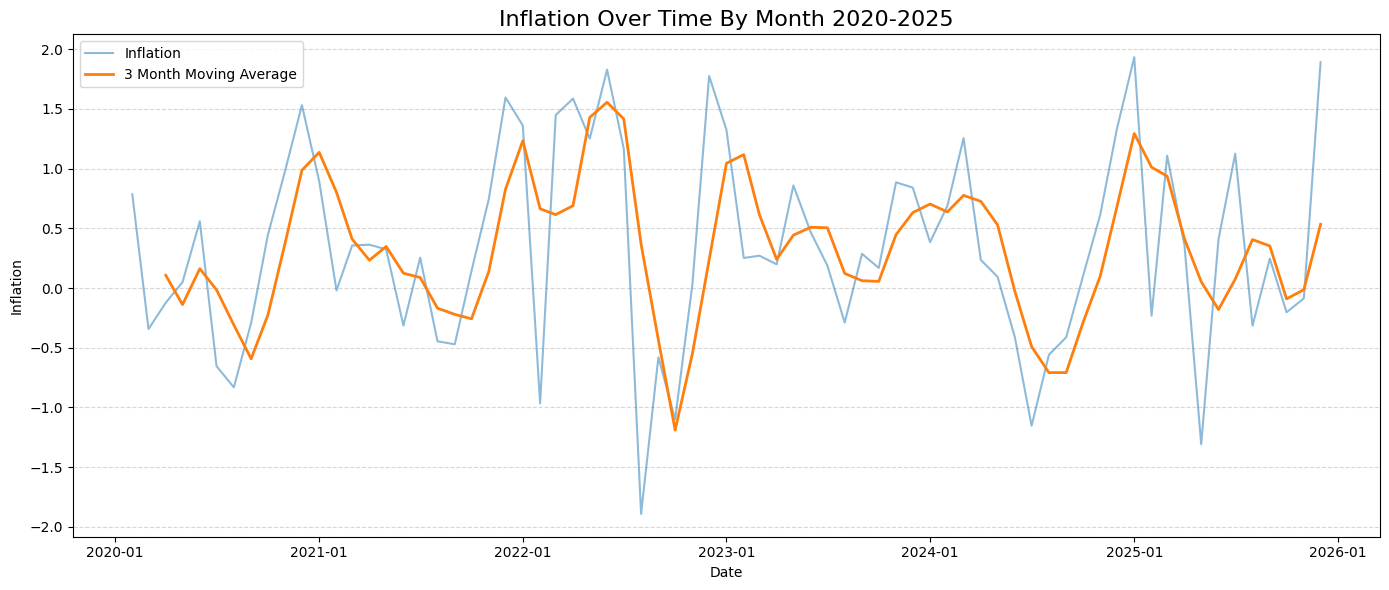

In [34]:
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['inflation'], label='Inflation', alpha=0.5)

plt.plot(df['date'], df['inflation'].rolling(window=3).mean(), label='3 Month Moving Average', linewidth=2)
plt.title('Inflation Over Time By Month 2020-2025', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Inflation')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())# Show only 10 x-ticks
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))# Format x-ticks as 'YYYY-MM'

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

###
Inflasi pangan menunjukkan pola yang tidak stabil dan cenderung dipengaruhi oleh shock harga komoditas, bukan tren linear jangka panjang.

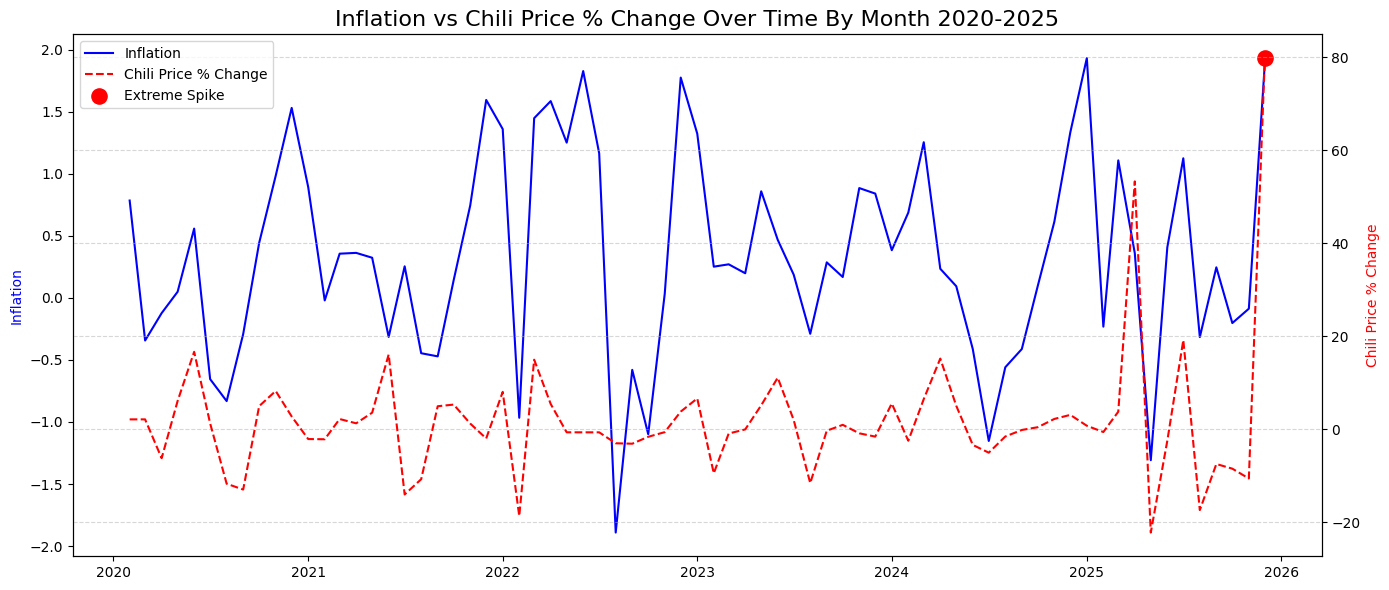

In [46]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(df['date'], df['inflation'], label='Inflation', color='blue')
ax1.set_ylabel('Inflation', color='blue')

ax2 = ax1.twinx()
ax2.plot(df['date'], df['chili_price_pct_change'],linestyle='--', label='Chili Price % Change', color='red')
ax2.set_ylabel('Chili Price % Change', color='red')

max_idx = df['chili_price_pct_change'].idxmax()
plt.scatter(df.loc[max_idx, 'date'], df.loc[max_idx, 'chili_price_pct_change'], color='red', s=120, label='Extreme Spike')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Inflation vs Chili Price % Change Over Time By Month 2020-2025', fontsize=16)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

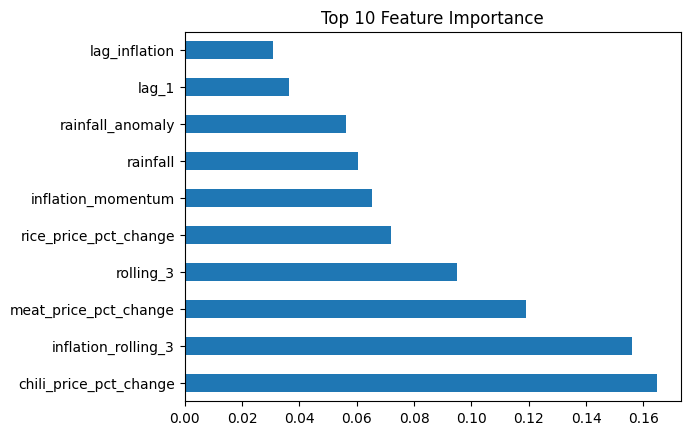

In [56]:
import pickle
import pandas as pd
xgb_model = None
X_train = None
with open('../model/xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

df = pd.read_csv('../dataset/final_dataset.csv')
X = df.drop(columns=['inflation', 'date'])  

columns = X.columns

feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=columns
).sort_values(ascending=False)

feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importance")
plt.show()

Insight Model: Faktor Penentu Inflasi Pangan

Berdasarkan hasil feature importance dari model XGBoost, perubahan harga cabai (chili_price_pct_change) merupakan faktor paling dominan dalam mempengaruhi prediksi inflasi pangan. Hal ini menunjukkan bahwa volatilitas harga cabai menjadi driver utama fluktuasi inflasi di Indonesia.

Selain itu, fitur berbasis historis seperti inflation_rolling_3 memiliki kontribusi besar, yang mengindikasikan bahwa inflasi bersifat autoregressive dan dipengaruhi oleh pola pada periode sebelumnya.

Komoditas lain seperti daging juga berkontribusi terhadap inflasi, namun dengan pengaruh yang lebih kecil dibandingkan cabai. Sementara itu, variabel curah hujan memiliki kontribusi rendah, yang menunjukkan bahwa pengaruhnya terhadap inflasi bersifat tidak langsung.

Temuan ini menegaskan bahwa perubahan harga komoditas, khususnya cabai, dapat digunakan sebagai indikator awal (leading indicator) untuk mengantisipasi pergerakan inflasi pangan.